<a href="https://colab.research.google.com/github/DarshanAryaKalasapura/Data_scientist/blob/main/Zomato_Data_Analysis_Using_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/pavankumarennamuri/zomata-data-set/zomato.csv


In [ ]:
df = pd.read_csv("/kaggle/input/datasets/pavankumarennamuri/zomata-data-set/zomato.csv")
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          51717 non-null  object
 1   address                      51717 non-null  object
 2   name                         51717 non-null  object
 3   online_order                 51717 non-null  object
 4   book_table                   51717 non-null  object
 5   rate                         43942 non-null  object
 6   votes                        51717 non-null  int64 
 7   phone                        50509 non-null  object
 8   location                     51696 non-null  object
 9   rest_type                    51490 non-null  object
 10  dish_liked                   23639 non-null  object
 11  cuisines                     51672 non-null  object
 12  approx_cost(for two people)  51371 non-null  object
 13  reviews_list                 51

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
votes,51717.0,283.697527,803.838853,0.0,7.0,41.0,198.0,16832.0


In [ ]:

df = df.drop_duplicates()

In [ ]:
df.shape

(51717, 17)

In [ ]:
print(df.isnull().sum())

url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
phone                           1208
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64


In [ ]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
print(missing_percentage)

url                             0.000000
address                         0.000000
name                            0.000000
online_order                    0.000000
book_table                      0.000000
rate                           15.033741
votes                           0.000000
phone                           2.335789
location                        0.040606
rest_type                       0.438927
dish_liked                     54.291626
cuisines                        0.087012
approx_cost(for two people)     0.669026
reviews_list                    0.000000
menu_item                       0.000000
listed_in(type)                 0.000000
listed_in(city)                 0.000000
dtype: float64


In [ ]:
df =df.dropna()
print(df.isnull().sum())

url                            0
address                        0
name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
phone                          0
location                       0
rest_type                      0
dish_liked                     0
cuisines                       0
approx_cost(for two people)    0
reviews_list                   0
menu_item                      0
listed_in(type)                0
listed_in(city)                0
dtype: int64


In [ ]:
# Force convert to string first, then clean, then convert to numeric float
df['rate'] = df['rate'].astype(str).str.replace('/5', '').str.strip()
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')


In [ ]:
df["approx_cost(for two people)"] = df["approx_cost(for two people)"].str.replace(",","")

df["approx_cost(for two people)"] = pd.to_numeric(
    df["approx_cost(for two people)"]
)

In [ ]:
print(df.describe())

print(df.describe(include="object").T)

               rate         votes  approx_cost(for two people)
count  23046.000000  23193.000000                 23193.000000
mean       3.904383    601.074462                   755.904368
std        0.426365   1114.854301                   521.448320
min        1.800000      0.000000                    40.000000
25%        3.800000    101.000000                   400.000000
50%        4.000000    221.000000                   600.000000
75%        4.200000    586.000000                  1000.000000
max        4.900000  16832.000000                  6000.000000
                 count unique  \
url              23193  23193   
address          23193   4371   
name             23193   3159   
online_order     23193      2   
book_table       23193      2   
phone            23193   6809   
location         23193     88   
rest_type        23193     73   
dish_liked       23193   5189   
cuisines         23193   1687   
reviews_list     23193  13998   
menu_item        23193   5026   
list

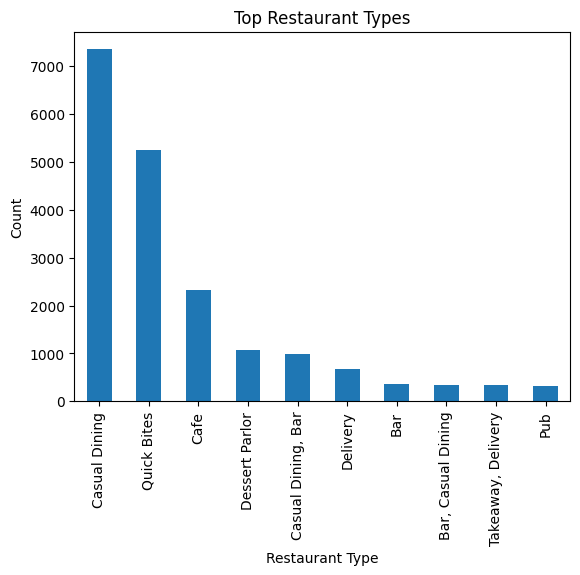

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns  # Optional, but highly recommended for Zomato charts

restaurant_type = df["rest_type"].value_counts().head(10)

restaurant_type.plot(kind="bar")

plt.title("Top Restaurant Types")

plt.xlabel("Restaurant Type")

plt.ylabel("Count")

plt.show()

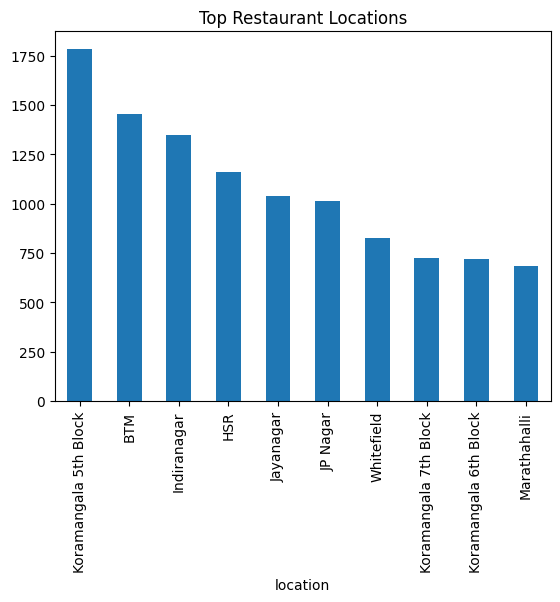

In [ ]:
top_locations = df["location"].value_counts().head(10)

top_locations.plot(kind="bar")

plt.title("Top Restaurant Locations")

plt.show()

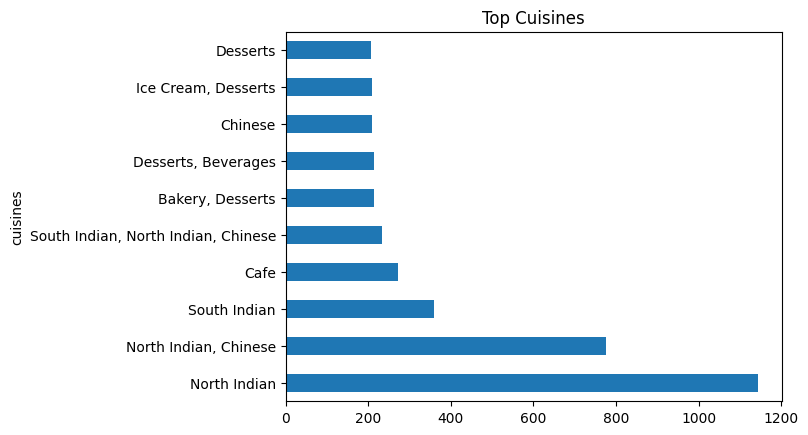

In [ ]:
top_cuisine = df["cuisines"].value_counts().head(10)

top_cuisine.plot(kind="barh")

plt.title("Top Cuisines")

plt.show()

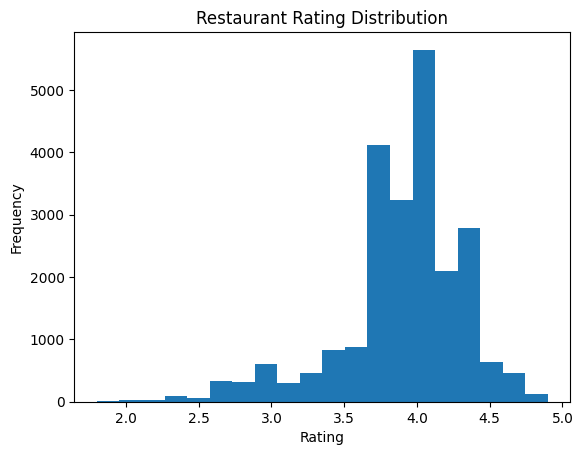

In [ ]:
plt.hist(df["rate"].dropna(), bins=20)

plt.title("Restaurant Rating Distribution")

plt.xlabel("Rating")

plt.ylabel("Frequency")

plt.show()

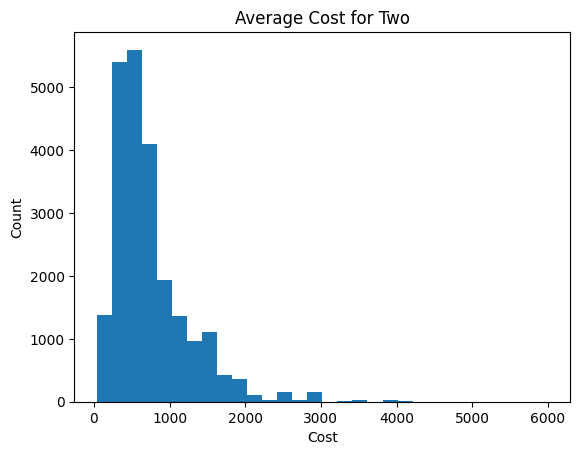

In [ ]:
plt.hist(df["approx_cost(for two people)"].dropna(), bins=30)

plt.title("Average Cost for Two")

plt.xlabel("Cost")

plt.ylabel("Count")

plt.show()

In [ ]:
print(df["online_order"].value_counts())

online_rating = df.groupby("online_order")["rate"].mean()

print(online_rating)

online_order
Yes    16358
No      6835
Name: count, dtype: int64
online_order
No     3.930227
Yes    3.893680
Name: rate, dtype: float64


In [ ]:
table_booking = df.groupby("book_table")["rate"].mean()

print(table_booking)

book_table
No     3.813349
Yes    4.160636
Name: rate, dtype: float64


In [ ]:
top = df.sort_values("rate",ascending=False)

print(top[["name","location","rate"]].head(20))

                                 name               location  rate
35082  Asia Kitchen By Mainland China  Koramangala 5th Block   4.9
49627     Byg Brewski Brewing Company          Sarjapur Road   4.9
23587       AB's - Absolute Barbecues                    BTM   4.9
34734  Asia Kitchen By Mainland China  Koramangala 5th Block   4.9
27453  Asia Kitchen By Mainland China  Koramangala 5th Block   4.9
39559                    Punjab Grill           Malleshwaram   4.9
11504  Asia Kitchen By Mainland China  Koramangala 5th Block   4.9
49170     Byg Brewski Brewing Company          Sarjapur Road   4.9
37099       AB's - Absolute Barbecues                    BTM   4.9
50059     Byg Brewski Brewing Company          Sarjapur Road   4.9
10879  Asia Kitchen By Mainland China  Koramangala 5th Block   4.9
29560  Asia Kitchen By Mainland China  Koramangala 5th Block   4.9
3921      Byg Brewski Brewing Company          Sarjapur Road   4.9
6746                         Flechazo             Whitefield  

In [ ]:
popular = df.sort_values("votes",ascending=False)

print(popular[["name","votes","rate"]].head(20))

                              name  votes  rate
50059  Byg Brewski Brewing Company  16832   4.9
49170  Byg Brewski Brewing Company  16832   4.9
49627  Byg Brewski Brewing Company  16832   4.9
3921   Byg Brewski Brewing Company  16345   4.9
4944   Byg Brewski Brewing Company  16345   4.9
4801   Byg Brewski Brewing Company  16345   4.9
18643                         Toit  14956   4.7
19268                         Toit  14956   4.7
36668                     Truffles  14726   4.7
33913                     Truffles  14723   4.7
34779                     Truffles  14723   4.7
36000                     Truffles  14723   4.7
32152                     Truffles  14717   4.7
33312                     Truffles  14717   4.7
29303                     Truffles  14710   4.7
29414                     Truffles  14710   4.7
31055                     Truffles  14710   4.7
28384                     Truffles  14704   4.7
27806                     Truffles  14694   4.7
26549                     Truffles  1469

In [ ]:
city_rating = df.groupby("listed_in(city)")["rate"].mean()

print(city_rating.sort_values(ascending=False))

listed_in(city)
Church Street            3.994791
Residency Road           3.987381
Lavelle Road             3.987374
Brigade Road             3.986203
MG Road                  3.983217
Koramangala 5th Block    3.972776
Koramangala 7th Block    3.971629
Koramangala 6th Block    3.968957
Koramangala 4th Block    3.960781
Malleshwaram             3.942073
BTM                      3.924359
Indiranagar              3.917310
Rajajinagar              3.915508
Frazer Town              3.911213
Old Airport Road         3.896242
Jayanagar                3.881958
Basavanagudi             3.879798
Kalyan Nagar             3.859302
HSR                      3.850137
New BEL Road             3.847872
Kammanahalli             3.845472
JP Nagar                 3.826452
Banashankari             3.826075
Whitefield               3.812440
Bellandur                3.808782
Sarjapur Road            3.779234
Marathahalli             3.738934
Bannerghatta Road        3.732037
Brookefield              3.70537

In [ ]:
cost = df.groupby("rest_type")[
    "approx_cost(for two people)"
].mean()

print(cost.sort_values())

rest_type
Dessert Parlor, Kiosk         200.000000
Quick Bites, Sweet Shop       212.195122
Mess                          257.142857
Sweet Shop                    285.784314
Sweet Shop, Quick Bites       286.931818
                                ...     
Bar, Lounge                  2450.000000
Fine Dining                  2748.076923
Fine Dining, Lounge          3000.000000
Fine Dining, Microbrewery    3000.000000
Fine Dining, Bar             3002.500000
Name: approx_cost(for two people), Length: 73, dtype: float64


In [ ]:
numeric = df[["votes","rate","approx_cost(for two people)"]]

print(numeric.corr())

                                votes      rate  approx_cost(for two people)
votes                        1.000000  0.382114                     0.307821
rate                         0.382114  1.000000                     0.315253
approx_cost(for two people)  0.307821  0.315253                     1.000000


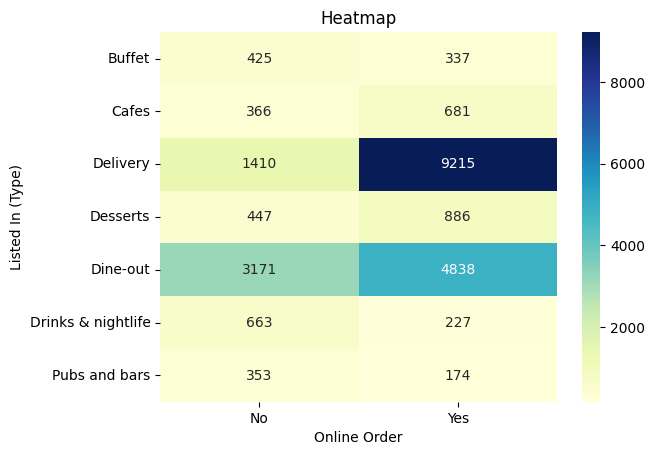

In [ ]:
pivot_table = df.pivot_table(index='listed_in(type)', columns='online_order', aggfunc='size', fill_value=0)
sns.heatmap(pivot_table, annot=True, cmap='YlGnBu', fmt='d')
plt.title('Heatmap')
plt.xlabel('Online Order')
plt.ylabel('Listed In (Type)')
plt.show()

<Axes: xlabel='online_order', ylabel='rate'>

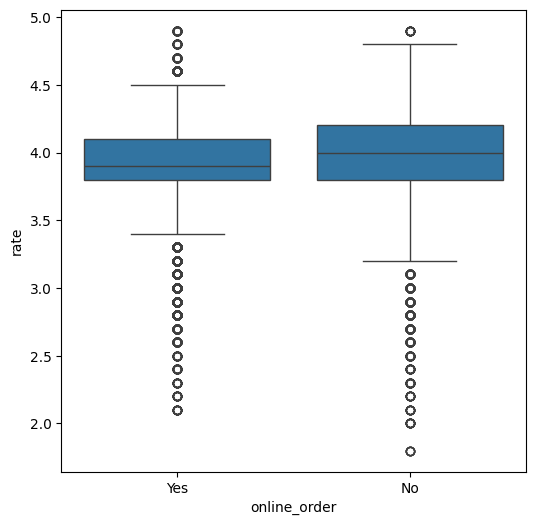

In [ ]:
plt.figure(figsize = (6,6))
sns.boxplot(x = 'online_order', y = 'rate', data = df)